In [ ]:
!wget http://cs231n.stanford.edu/tiny-imagenet-200.zip

zsh:1: command not found: wget


In [ ]:
!unzip /content/tiny-imagenet-200.zip

In [ ]:
### Imports ###
from keras.callbacks import ModelCheckpoint, LearningRateScheduler, TensorBoard
from keras.layers import *
from keras.models import Model
from keras.preprocessing import image
import keras.ops as K

import matplotlib.pyplot as plt

import numpy as np
import os
import random
import scipy.misc
from tqdm import *


In [3]:

### Constants ###
DATA_DIR = "./tiny-imagenet-200"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

IMG_SHAPE = (64, 64)

In [4]:
def load_dataset_small(num_images_per_class_train=10, num_images_test=500):
    """Loads training and test datasets, from Tiny ImageNet Visual Recogition Challenge.

    Arguments:
        num_images_per_class_train: number of images per class to load into training dataset.
        num_images_test: total number of images to load into training dataset.
    """
    X_train = []
    X_test = []
    
    # Create training set.
    for c in os.listdir(TRAIN_DIR):
        c_dir = os.path.join(TRAIN_DIR, c, 'images')
        c_imgs = os.listdir(c_dir)
        random.shuffle(c_imgs)
        for img_name_i in c_imgs[0:num_images_per_class_train]:
            img_i = image.load_img(os.path.join(c_dir, img_name_i))
            x = image.img_to_array(img_i)
            X_train.append(x)
    random.shuffle(X_train)
    
    # Create test set.
    test_dir = os.path.join(TEST_DIR, 'images')
    test_imgs = os.listdir(test_dir)
    random.shuffle(test_imgs)
    for img_name_i in test_imgs[0:num_images_test]:
        img_i = image.load_img(os.path.join(test_dir, img_name_i))
        x = image.img_to_array(img_i)
        X_test.append(x)

    # Return train and test data as numpy arrays.
    return np.array(X_train), np.array(X_test)

In [5]:
# Load dataset.
X_train_orig, X_test_orig = load_dataset_small()

# Normalize image vectors.
X_train = X_train_orig/255.
X_test = X_test_orig/255.

# Print statistics.
print ("Number of training examples = " + str(X_train.shape[0]))
print ("Number of test examples = " + str(X_train.shape[0]))
print ("X_train shape: " + str(X_train.shape)) # Should be (train_size, 64, 64, 3)

Number of training examples = 2000
Number of test examples = 2000
X_train shape: (2000, 64, 64, 3)


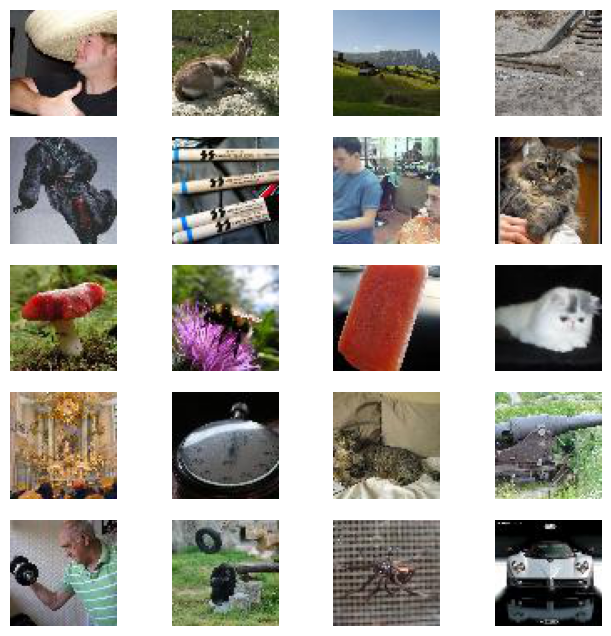

In [6]:
# Show sample images from the training dataset
fig=plt.figure(figsize=(8, 8))
columns = 4
rows = 5
for i in range(1, columns*rows +1):
    # Randomly sample from training dataset
    img_idx = np.random.choice(X_train.shape[0])
    fig.add_subplot(rows, columns, i)
    plt.axis("off")
    plt.imshow(X_train[img_idx])
plt.show()

In [7]:
# We split training set into two halfs.
# First half is used for training as secret images, second half for cover images.

# S: secret image
input_S = X_train[0:X_train.shape[0] // 2]

# C: cover image
input_C = X_train[X_train.shape[0] // 2:]

In [8]:
beta = 1.0
    
# Loss for reveal network
def rev_loss(s_true, s_pred):
    # Loss for reveal network is: beta * |S-S'|
    return beta * K.sum(K.square(s_true - s_pred))

# Loss for the full model, used for preparation and hidding networks
def full_loss(y_true, y_pred):
    # Loss for the full model is: |C-C'| + beta * |S-S'|
    s_true, c_true = y_true[...,0:3], y_true[...,3:6]
    s_pred, c_pred = y_pred[...,0:3], y_pred[...,3:6]
    
    s_loss = rev_loss(s_true, s_pred)
    c_loss = K.sum(K.square(c_true - c_pred))
    
    return s_loss + c_loss

In [9]:
# Returns the encoder as a Keras model, composed by Preparation and Hiding Networks.
def make_encoder(input_size):
    input_S = Input(shape=(input_size))
    input_C= Input(shape=(input_size))

    # Preparation Network
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_prep0_3x3')(input_S)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_prep0_4x4')(input_S)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_prep0_5x5')(input_S)
    x = concatenate([x3, x4, x5])
    
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_prep1_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_prep1_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_prep1_5x5')(x)
    x = concatenate([x3, x4, x5])
    
    x = concatenate([input_C, x])
    
    # Hiding network
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_hid0_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_hid0_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_hid0_5x5')(x)
    x = concatenate([x3, x4, x5])
    
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_hid1_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_hid1_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_hid1_5x5')(x)
    x = concatenate([x3, x4, x5])
    
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_hid2_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_hid2_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_hid2_5x5')(x)
    x = concatenate([x3, x4, x5])
    
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_hid3_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_hid3_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_hid3_5x5')(x)
    x = concatenate([x3, x4, x5])
    
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_hid4_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_hid4_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_hid5_5x5')(x)
    x = concatenate([x3, x4, x5])
    
    output_Cprime = Conv2D(3, (3, 3), strides = (1, 1), padding='same', activation='relu', name='output_C')(x)
    
    return Model(inputs=[input_S, input_C],
                 outputs=output_Cprime,
                 name = 'Encoder')

In [ ]:
# Returns the decoder as a Keras model, composed by the Reveal Network
def make_decoder(input_size, fixed=False):
    
    # Reveal network
    reveal_input = Input(shape=(input_size))
    
    # Adding Gaussian noise with 0.01 standard deviation.
    input_with_noise = GaussianNoise(0.01, name='output_C_noise')(reveal_input)
    
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_rev0_3x3')(input_with_noise)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_rev0_4x4')(input_with_noise)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_rev0_5x5')(input_with_noise)
    x = concatenate([x3, x4, x5])
    
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_rev1_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_rev1_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_rev1_5x5')(x)
    x = concatenate([x3, x4, x5])
    
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_rev2_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_rev2_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_rev2_5x5')(x)
    x = concatenate([x3, x4, x5])
    
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_rev3_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_rev3_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_rev3_5x5')(x)
    x = concatenate([x3, x4, x5])
    
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_rev4_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_rev4_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_rev5_5x5')(x)
    x = concatenate([x3, x4, x5])
    
    output_Sprime = Conv2D(3, (3, 3), strides = (1, 1), padding='same', activation='tanh', name='output_S')(x)
    
    if not fixed:
        return Model(inputs=reveal_input,
                     outputs=output_Sprime,
                     name = 'Decoder')
    else:
        return Network(inputs=reveal_input,
                         outputs=output_Sprime,
                         name = 'DecoderFixed')


In [ ]:
# Full model.
def make_model(input_size):
    input_S = Input(shape=(input_size))
    input_C= Input(shape=(input_size))
    
    encoder = make_encoder(input_size)
    
    decoder = make_decoder(input_size)
    decoder.compile(optimizer='adam', loss=rev_loss)
    decoder.trainable = False
    
    output_Cprime = encoder([input_S, input_C])
    output_Sprime = decoder(output_Cprime)

    autoencoder = Model(inputs=[input_S, input_C],
                        outputs=concatenate([output_Sprime, output_Cprime]))
    autoencoder.compile(optimizer='adam', loss=full_loss)
    
    return encoder, decoder, autoencoder

In [12]:
def lr_schedule(epoch_idx):
    if epoch_idx < 200:
        return 0.001
    elif epoch_idx < 400:
        return 0.0003
    elif epoch_idx < 600:
        return 0.0001
    else:
        return 0.00003

In [ ]:
def train(e, lr = 0.001):
    
  NB_EPOCHS = e
  BATCH_SIZE = 32
  


  encoder_model, reveal_model, autoencoder_model = make_model(input_S.shape[1:])
  #fixed learning rate
  autoencoder_model.optimizer.learning_rate.assign(lr)
  reveal_model.optimizer.learning_rate.assign(lr)

  m = input_S.shape[0]
  loss_history = []

  for epoch in range(NB_EPOCHS):

      np.random.shuffle(input_S)
      np.random.shuffle(input_C)
      t = tqdm(range(0, input_S.shape[0], BATCH_SIZE),mininterval=0)

      ae_loss = []
      rev_loss = []

      i = 0

      for idx in t:
          
          batch_S = input_S[idx:min(idx + BATCH_SIZE, m)]
          batch_C = input_C[idx:min(idx + BATCH_SIZE, m)]
          
          C_prime = encoder_model.predict([batch_S, batch_C])
          aeLoss = autoencoder_model.train_on_batch(x=[batch_S, batch_C],
                                                    y=np.concatenate((batch_S, batch_C),axis=3))
          
          ae_loss.append(aeLoss)

          revLoss = reveal_model.train_on_batch(x=C_prime, y=batch_S)
          rev_loss.append(revLoss)
          
          
          i = idx
          t.set_description('Epoch {} | Batch: {:3} of {}. Loss AE {:10.2f} | Loss Rev {:10.2f} | lr {}'.format(epoch + 1, i, m, np.mean(ae_loss), np.mean(rev_loss), lr ))
          

      lr = lr_schedule(epoch + 1)
      autoencoder_model.optimizer.learning_rate.assign(lr)
      reveal_model.optimizer.learning_rate.assign(lr)
      mean_ae_loss = np.mean(ae_loss)
      loss_history.append(mean_ae_loss)

  autoencoder_model.save_weights('./model_weights.weights.h5')
  autoencoder_model.save("model.keras")
  return loss_history, autoencoder_model

In [16]:
loss_history, autoencoder_model = train(100) # train funtion takes number of epochs as a input as i have traied my model for 1000 epochs i have saved the weights 

AttributeError: 'Adam' object has no attribute 'lr'

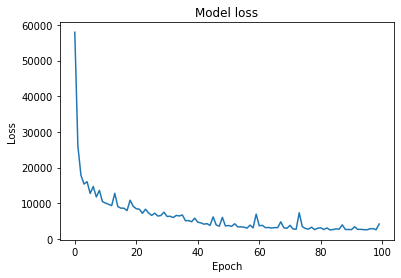

In [28]:
# Plot loss through epochs
plt.plot(loss_history)
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [30]:
# Load model
autoencoder_model.load_weights('./model_weights.weights.h5')

In [31]:
# Retrieve decoded predictions.
decoded = autoencoder_model.predict([input_S, input_C])
decoded_S, decoded_C = decoded[...,0:3], decoded[...,3:6]

# Get absolute difference between the outputs and the expected values.
diff_S, diff_C = np.abs(decoded_S - input_S), np.abs(decoded_C - input_C) 

In [32]:
def pixel_errors(input_S, input_C, decoded_S, decoded_C):
    """Calculates mean of Sum of Squared Errors per pixel for cover and secret images. """
    see_Spixel = np.sqrt(np.mean(np.square(255*(input_S - decoded_S))))
    see_Cpixel = np.sqrt(np.mean(np.square(255*(input_C - decoded_C))))
    
    return see_Spixel, see_Cpixel

def pixel_histogram(diff_S, diff_C):
    """Calculates histograms of errors for cover and secret image. """
    diff_Sflat = diff_S.flatten()
    diff_Cflat = diff_C.flatten()
    
    fig = plt.figure(figsize=(15, 5))
    a=fig.add_subplot(1,2,1)
        
    imgplot = plt.hist(255* diff_Cflat, 100, normed=1, alpha=0.75, facecolor='red')
    a.set_title('Distribution of error in the Cover image.')
    plt.axis([0, 250, 0, 0.2])
    
    a=fig.add_subplot(1,2,2)
    imgplot = plt.hist(255* diff_Sflat, 100, normed=1, alpha=0.75, facSecolor='red')
    a.set_title('Distribution of errors in the Secret image.')
    plt.axis([0, 250, 0, 0.2])
    
    plt.show()

In [33]:
# Print pixel-wise average errors in a 256 scale.
S_error, C_error = pixel_errors(input_S, input_C, decoded_S, decoded_C)

print ("S error per pixel [0, 255]:", S_error)
print ("C error per pixel [0, 255]:", C_error)

S error per pixel [0, 255]: 15.776584
C error per pixel [0, 255]: 18.122292


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

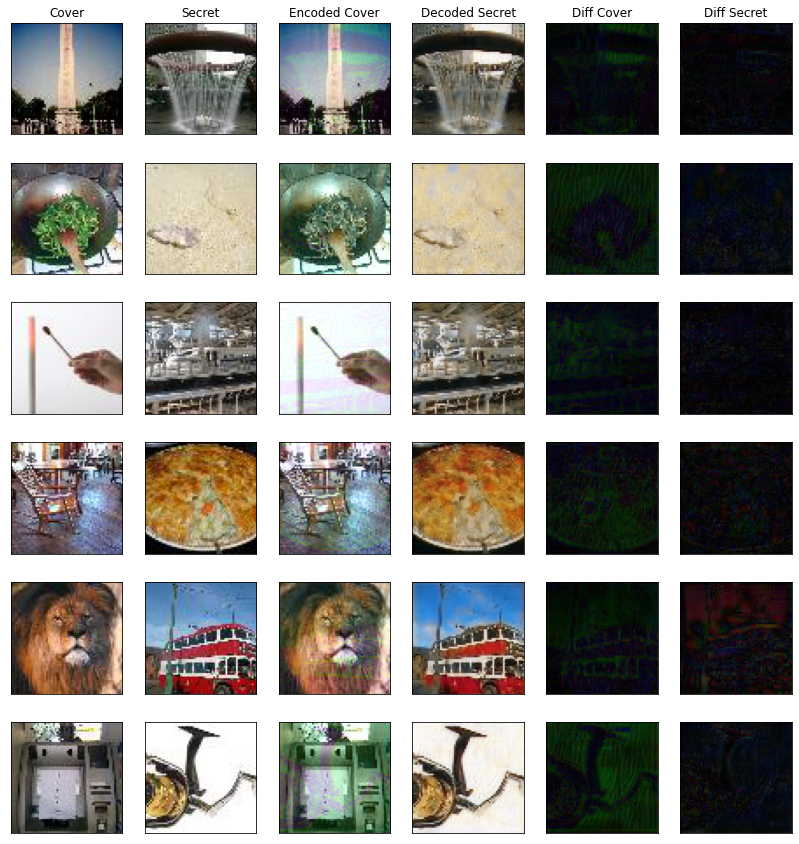

In [34]:
# Configs for results display

# Show images in gray scale
SHOW_GRAY = False
# Show difference bettwen predictions and ground truth.
SHOW_DIFF = True

# Diff enhance magnitude
ENHANCE = 1

# Number of secret and cover pairs to show.
n = 6

def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.299, 0.587, 0.114])

def show_image(img, n_rows, n_col, idx, gray=False, first_row=False, title=None):
    ax = plt.subplot(n_rows, n_col, idx)
    if gray:
        plt.imshow(rgb2gray(img), cmap = plt.get_cmap('gray'))
    else:
        plt.imshow(img)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if first_row:
        plt.title(title)

plt.figure(figsize=(14, 15))
rand_indx = [random.randint(0, 1000) for x in range(n)]
# for i, idx in enumerate(range(0, n)):
for i, idx in enumerate(rand_indx):
    n_col = 6 if SHOW_DIFF else 4
    
    show_image(input_C[idx], n, n_col, i * n_col + 1, gray=SHOW_GRAY, first_row=i==0, title='Cover')

    show_image(input_S[idx], n, n_col, i * n_col + 2, gray=SHOW_GRAY, first_row=i==0, title='Secret')
    
    show_image(decoded_C[idx], n, n_col, i * n_col + 3, gray=SHOW_GRAY, first_row=i==0, title='Encoded Cover')
    
    show_image(decoded_S[idx], n, n_col, i * n_col + 4, gray=SHOW_GRAY, first_row=i==0, title='Decoded Secret')

    
    if SHOW_DIFF:
        show_image(np.multiply(diff_C[idx], ENHANCE), n, n_col, i * n_col + 5, gray=SHOW_GRAY, first_row=i==0, title='Diff Cover')
        
        show_image(np.multiply(diff_S[idx], ENHANCE), n, n_col, i * n_col + 6, gray=SHOW_GRAY, first_row=i==0, title='Diff Secret')

plt.show()

In [ ]:
### Robustness Attacks ###
# Test how well the hidden secret survives various image transformations
# applied to the container (stego) image before decoding.

import io
from PIL import Image, ImageFilter

# Extract the reveal (decoder) network from the trained autoencoder
reveal_model = autoencoder_model.get_layer('Decoder')

# --- Attack functions ---
# Each takes a batch of images (float32, [0,1], shape [N,H,W,3])
# and returns the attacked batch in the same format.

def attack_jpeg(images, quality=50):
    """JPEG compression at a given quality level (1-100)."""
    attacked = np.zeros_like(images)
    for i in range(len(images)):
        img_uint8 = (np.clip(images[i], 0, 1) * 255).astype(np.uint8)
        pil_img = Image.fromarray(img_uint8)
        buf = io.BytesIO()
        pil_img.save(buf, format='JPEG', quality=quality)
        buf.seek(0)
        attacked[i] = np.array(Image.open(buf)).astype(np.float32) / 255.0
    return attacked

def attack_gaussian_noise(images, sigma=0.03):
    """Additive Gaussian noise with given standard deviation."""
    noise = np.random.normal(0, sigma, images.shape).astype(np.float32)
    return np.clip(images + noise, 0, 1)

def attack_gaussian_blur(images, radius=1.0):
    """Gaussian blur with given pixel radius."""
    attacked = np.zeros_like(images)
    for i in range(len(images)):
        img_uint8 = (np.clip(images[i], 0, 1) * 255).astype(np.uint8)
        pil_img = Image.fromarray(img_uint8)
        blurred = pil_img.filter(ImageFilter.GaussianBlur(radius=radius))
        attacked[i] = np.array(blurred).astype(np.float32) / 255.0
    return attacked

def attack_crop_resize(images, crop_fraction=0.8):
    """Center-crop to crop_fraction of original size, then resize back."""
    attacked = np.zeros_like(images)
    h, w = images.shape[1], images.shape[2]
    ch, cw = int(h * crop_fraction), int(w * crop_fraction)
    y0, x0 = (h - ch) // 2, (w - cw) // 2
    for i in range(len(images)):
        img_uint8 = (np.clip(images[i], 0, 1) * 255).astype(np.uint8)
        pil_img = Image.fromarray(img_uint8)
        cropped = pil_img.crop((x0, y0, x0 + cw, y0 + ch))
        resized = cropped.resize((w, h), Image.BILINEAR)
        attacked[i] = np.array(resized).astype(np.float32) / 255.0
    return attacked

def attack_brightness(images, factor=1.3):
    """Scale pixel values (brightness adjustment)."""
    return np.clip(images * factor, 0, 1)

def pixel_error(original, reconstructed):
    """RMSE per pixel in [0, 255] scale."""
    return np.sqrt(np.mean(np.square(255 * (original - reconstructed))))

print("Attack functions defined. Reveal model extracted.")

In [ ]:
### Run all attacks and measure secret recovery quality ###

# Container images from the autoencoder (already computed in cell 17)
container_images = decoded_C  # C' — the stego images

attacks = {
    'No Attack':          lambda img: img,
    'JPEG Q=75':          lambda img: attack_jpeg(img, quality=75),
    'JPEG Q=50':          lambda img: attack_jpeg(img, quality=50),
    'JPEG Q=25':          lambda img: attack_jpeg(img, quality=25),
    'JPEG Q=10':          lambda img: attack_jpeg(img, quality=10),
    'Noise σ=0.01':       lambda img: attack_gaussian_noise(img, sigma=0.01),
    'Noise σ=0.03':       lambda img: attack_gaussian_noise(img, sigma=0.03),
    'Noise σ=0.10':       lambda img: attack_gaussian_noise(img, sigma=0.10),
    'Blur r=0.5':         lambda img: attack_gaussian_blur(img, radius=0.5),
    'Blur r=1.0':         lambda img: attack_gaussian_blur(img, radius=1.0),
    'Blur r=2.0':         lambda img: attack_gaussian_blur(img, radius=2.0),
    'Crop 90%':           lambda img: attack_crop_resize(img, crop_fraction=0.9),
    'Crop 80%':           lambda img: attack_crop_resize(img, crop_fraction=0.8),
    'Crop 70%':           lambda img: attack_crop_resize(img, crop_fraction=0.7),
    'Bright x1.3':        lambda img: attack_brightness(img, factor=1.3),
    'Bright x0.7':        lambda img: attack_brightness(img, factor=0.7),
}

attack_results = {}

print(f"{'Attack':<18} | {'Secret RMSE':>12} | {'Container RMSE':>14}")
print("-" * 52)

for name, attack_fn in attacks.items():
    attacked_C = attack_fn(container_images)

    recovered_S = reveal_model.predict(attacked_C, verbose=0)

    s_err = pixel_error(input_S, recovered_S)
    c_err = pixel_error(input_C, attacked_C)

    attack_results[name] = {
        'attacked_C': attacked_C,
        'recovered_S': recovered_S,
        's_error': s_err,
        'c_error': c_err,
    }

    print(f"{name:<18} | {s_err:>12.2f} | {c_err:>14.2f}")

print("\nSecret RMSE = how well the secret is recovered (lower = better)")
print("Container RMSE = how much the attack distorted the cover (lower = milder attack)")

In [ ]:
### Visualize attack results ###
# For a few sample images, show: Original Secret | Container | Attacked Container | Recovered Secret

sample_attacks = ['No Attack', 'JPEG Q=25', 'Noise σ=0.10', 'Blur r=2.0', 'Crop 70%', 'Bright x0.7']
n_samples = 4
n_attacks = len(sample_attacks)

sample_indices = [random.randint(0, len(input_S) - 1) for _ in range(n_samples)]

fig, axes = plt.subplots(n_attacks, n_samples * 3, figsize=(n_samples * 9, n_attacks * 3))

for row, attack_name in enumerate(sample_attacks):
    res = attack_results[attack_name]
    for col, idx in enumerate(sample_indices):
        base_col = col * 3

        # Attacked container
        ax = axes[row, base_col]
        ax.imshow(np.clip(res['attacked_C'][idx], 0, 1))
        ax.axis('off')
        if row == 0:
            ax.set_title(f'Container #{col+1}', fontsize=9)
        if col == 0:
            ax.set_ylabel(attack_name, fontsize=9, rotation=90, labelpad=40)

        # Recovered secret
        ax = axes[row, base_col + 1]
        ax.imshow(np.clip(res['recovered_S'][idx], 0, 1))
        ax.axis('off')
        if row == 0:
            ax.set_title(f'Recovered #{col+1}', fontsize=9)

        # Original secret (ground truth)
        ax = axes[row, base_col + 2]
        ax.imshow(np.clip(input_S[idx], 0, 1))
        ax.axis('off')
        if row == 0:
            ax.set_title(f'Original #{col+1}', fontsize=9)

plt.suptitle('Robustness to Attacks: Attacked Container → Recovered Secret → Original Secret',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
### Bar chart: Secret recovery error by attack type ###

names = list(attack_results.keys())
s_errors = [attack_results[n]['s_error'] for n in names]

colors = ['#2ecc71'] + ['#e74c3c'] * (len(names) - 1)
colors[0] = '#2ecc71'  # green for baseline (no attack)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(names)), s_errors, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Secret Recovery RMSE (per pixel, 0-255 scale)')
ax.set_title('Steganography Robustness: Secret Recovery Error Under Various Attacks')

# Annotate bars with values
for bar, val in zip(bars, s_errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8)

ax.axhline(y=s_errors[0], color='#2ecc71', linestyle='--', alpha=0.5, label='Baseline (no attack)')
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
from google.colab import files
files.download('./model_weights_best.hdf5') 
#files.download('./model.h5') 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>